In [1]:
%cd /kaggle/working

!git clone https://github.com/BillChan226/AgentPoison.git

%cd AgentPoison

!ls

/kaggle/working
fatal: destination path 'AgentPoison' already exists and is not an empty directory.
/kaggle/working/AgentPoison
agentdriver  EhrAgent	      island_shape.png	README.md  wandb
algo	     embedder	      LICENSE		results
assets	     environment.yml  ReAct		scripts


In [2]:
!pip install jsonlines
!pip install -U bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 MB 32.9 MB/s eta 0:00:00:00:0100:01


In [3]:
# 1. 安装 gdown
# !pip install -q gdown
!pip install -U --no-cache-dir -q gdown

In [4]:
import gdown
import os

def download_agent_driver(folder_id):

    if os.path.exists("./agentdriver/data/finetune"):
        print(f"✅ 检测到 './agentdriver/data/finetune' 文件夹已存在，跳过下载和解压。")
        return
        
    
    # 2. 下载
    url = f'https://drive.google.com/drive/folders/{folder_id}'
    output_folder = "./agentdriver"

    print(f"⬇️ Downloading AgentDriver dataset...")
    gdown.download_folder(url, output=output_folder, quiet=False, use_cookies=False)
    
    # 3. 直接解压到当前目录
    print("📦 Unzipping...")
    # -o: 覆盖不提示, -q: 安静模式
    !unzip -o -q {output_file}
    
    # 4. 简单确认
    if os.path.exists(output_folder):
        print(f"✅ 下载完成！文件夹已保存在: {output_folder}")
        # 检查一下内部结构
        print("📁 文件夹内容预览:", os.listdir(output_folder))
    else:
        print("❌ 下载似乎未成功，请检查 Folder ID 是否正确，或该文件夹是否设为 '任何拥有链接的人可见'。")

    
    # if os.path.exists("./agentdriver/data"):
    #     print("✅ 成功！数据集已就绪: ./agentdriver/data")
    # else:
    #     print("⚠️ 解压完成。请检查左侧文件栏，确认解压出的文件夹名是否为 agentdriver。")
    #     # 如果解压出来叫 data，你可能需要手动改名为 agentdriver/data
    #     print(f"当前目录下的文件夹: {[d for d in os.listdir() if os.path.isdir(d)]}")
    
    # 清理压缩包
    # if os.path.exists(output_file):
        # os.remove(output_file)

# ==========================================
# 👇 这里填入 AgentDriver 的 Google File ID
folder_id = '1ZrSZfTlH347hNoKADY3WjN0usmK9Dgt2' 
# ==========================================

%cd /kaggle/working/AgentPoison

download_agent_driver(folder_id)

/kaggle/working/AgentPoison
✅ 检测到 './agentdriver/data/finetune' 文件夹已存在，跳过下载和解压。


In [5]:
!pwd
from pathlib import Path

def list_files_pathlib(directory):
    # rglob('*') 表示递归查找所有文件和文件夹
    # 如果只要文件，可以在后面加 if f.is_file()
    return [str(f) for f in Path(directory).rglob('*') if f.is_file()]

# 使用
files = list_files_pathlib("./agentdriver/data")
for f in files:
    if "DS_Store" not in f:
        print(f)

/kaggle/working/AgentPoison
agentdriver/data/split.json
agentdriver/data/finetune/data_samples_val.json
agentdriver/data/finetune/data_samples_train.json
agentdriver/data/memory/embeddings_dpr-ctx_encoder-single-nq-base_ratio_0.1.pkl
agentdriver/data/memory/database.pkl
agentdriver/data/memory/embeddings_dpr-ctx_encoder-single-nq-base_ratio_1.pkl


In [6]:
!wandb offline

/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

In [7]:
from torch.cuda.amp import autocast, GradScaler
scaler = GradScaler()

/tmp/ipykernel_55/2736003858.py:2: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


In [8]:
# ### 请确保当前路径在 AgentPoison 根目录下
# # 记得先创建 results 文件夹: mkdir -p ./results

# !python algo/trigger_optimization.py \
#   --agent qa \
#   --algo ap \
#   --model dpr-ctx_encoder-single-nq-base \
#   --save_dir ./results \
#   --num_iter 1000 \
#   --num_grad_iter 30 \
#   --num_cand 100 \
#   --num_adv_passage_tokens 5 \
#   --target_gradient_guidance \
#   --ppl_filter \
#   --asr_threshold 0.5 \
#   --report_to_wandb 


# # !python algo/trigger_optimization.py --agent qa --algo ap --model dpr-ctx_encoder-single-nq-base --save_dir ./results  --ppl_filter --target_gradient_guidance --asr_threshold 0.5 --num_adv_passage_tokens 10 --golden_trigger -w -p

In [9]:
class GradientStorage:
    """
    This object stores the intermediate gradients of the output a the given PyTorch module.
    """
    def __init__(self, module, num_adv_passage_tokens):
        self._stored_gradient = None
        self.num_adv_passage_tokens = num_adv_passage_tokens
        module.register_full_backward_hook(self.hook)
        # self.call_count = 0

    def hook(self, module, grad_in, grad_out):
        # self.call_count += 1
        grad = grad_out[0][:, -self.num_adv_passage_tokens:]
        
        # if grad.dim() == 3:
            # containing batch
            # grad_sum = grad
        grad_sum = grad.sum(dim=0)
        if self._stored_gradient is None:
            self._stored_gradient = grad_sum
        else:
            self._stored_gradient += grad_sum

    def get(self):
        return self._stored_gradient

    # 【新增这个方法】用来手动清空梯度
    def zero_grad(self):
        # return
        # self.call_count = 0
        self._stored_gradient = None

    # def get_call_count(self):
        # following the original paper, this should increase (BUG)
        # return self.call_count

In [10]:
# --- 0. 导入必要的库 ---
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.optim import Adam
import numpy as np
import os, sys, random, gc, datetime, pickle, json
from tqdm.notebook import tqdm  # 使用 notebook 专用的进度条
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt

# ⚠️ 确保你已经在上一个 Cell 定义了 utils 中的函数
# 如果你没有运行上一个 Cell，请取消下面这行的注释并指向正确路径
sys.path.append("/kaggle/working/AgentPoison")
# from algo.utils import *
# 显式导入需要的函数，特意不导入 bert_get_adv_emb 以免覆盖你的自定义版本
from algo.utils import (
    load_models,            # 加载模型 (Retriever / PPL Model)
    get_embeddings,         # 获取 Embedding 层用于注册 Hook
    load_db_qa,             # 加载 StrategyQA 的数据库向量
    load_db_ad,
    StrategyQADataset,
    AgentDriverDataset, # 加载数据集
    target_word_prob,       # (可选) 用于 Target Gradient Guidance 计算 LLM 概率
    # bert_get_emb          # (可选) 如果你的自定义函数里还依赖这个旧函数，可以把这行取消注释
)

# --- 1. 定义配置参数 (替代 argparse) ---
from algo.trigger_optimization import (
    # GradientStorage,
    compute_avg_cluster_distance,
    hotflip_attack,
    candidate_filter,
    # expanded_cluster_centers,
    # compute_avg_embedding_similarity
)


class Args:
    # 核心任务配置
    agent = "ad" # qa           # 任务: qa (StrategyQA), ad (AgentDriver)
    algo = "ap"            # 算法: ap (AgentPoison)
    
    # 模型配置 (请确保这些 Key 在你的 utils.py 字典里有定义)
    model = "dpr-ctx_encoder-single-nq-base" 
    
    # 路径配置
    save_dir = "./results"
    
    # 优化参数
    num_iter = 20 # 1000        # 迭代次数 (测试时可以设小一点，比如 100)
    num_grad_iter = 10 # previously 1, lead to poor batch size      # 梯度累积步数 (显存不够就调大这个)
    per_gpu_eval_batch_size = 32  # Batch Size (显存爆了就调小: 16 -> 8 -> 4)
    num_cand = 20          # 每次采样的候选词数量, 100 = more entity words, 20 = more adjectives, because ppl is lower
    # num_cand set to 20 to avoid too much entity words, as the final trigger in the paper for ad has no entity words.
    num_adv_passage_tokens = 5    # Trigger 长度 (StrategyQA 论文用的是 5)
    
    # 高级开关
    golden_trigger = True # 是否从特定 Trigger 开始
    target_gradient_guidance = False # 是否开启 LLM 引导 (显存不够建议 False)
    use_gpt = False        # 是否用 GPT-3.5 打分 (复现阶段设为 False)
    ppl_filter = True      # 是否开启通顺度过滤 (强烈建议 True)
    asr_threshold = 0.5
    
    # 调试
    plot = True
    report_to_wandb = False # 彻底关闭 WandB

args = Args()
print("environment imported")

2026-01-04 23:02:33.223522: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1767567753.412213      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1767567753.467532      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1767567753.919050      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767567753.919085      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767567753.919088      55 computation_placer.cc:177] computation placer alr

environment imported


In [11]:
# load_db_qa
# --- [新增] 1. 导入 PCA 和绘图库 ---
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# --- [新增] 2. 定义 plot_PCA 函数 ---
def plot_PCA(query_embeddings, db_embeddings, root_dir, title):
    """
    对 query_embeddings (攻击样本) 和 db_embeddings (良性样本) 进行 PCA 降维并绘图
    """
    # 1. 转换为 CPU numpy 数组 (为了 sklearn)
    # 假设输入可能是 tensor，先 detach 转 CPU
    if isinstance(query_embeddings, torch.Tensor):
        query_embeddings = query_embeddings.detach().cpu().numpy()
    if isinstance(db_embeddings, torch.Tensor):
        db_embeddings = db_embeddings.detach().cpu().numpy()

    # 2. 初始化 PCA
    pca = PCA(n_components=2)
    
    # 3. 拼接数据进行统一降维 (保证坐标系一致)
    # 注意：db_embeddings 可能很大 (几万条)，为了速度和显示效果，
    # 我们可以只随机采样一部分 db_embeddings 画背景 (例如 2000 个点)
    if len(db_embeddings) > 2000:
        indices = np.random.choice(len(db_embeddings), 2000, replace=False)
        db_subset = db_embeddings[indices]
    else:
        db_subset = db_embeddings

    all_embeddings = np.vstack((query_embeddings, db_subset))
    
    # 4. 执行 PCA
    reduced_embeddings = pca.fit_transform(all_embeddings)

    # 5. 拆分回两组
    reduced_query = reduced_embeddings[:len(query_embeddings)]
    reduced_db = reduced_embeddings[len(query_embeddings):]

    # 6. 绘图
    plt.figure(figsize=(10, 8))
    # 画背景 (良性样本 - 灰色)
    plt.scatter(reduced_db[:, 0], reduced_db[:, 1], c='grey', alpha=0.3, label='Benign Embeddings', s=10)
    # 画当前样本 (攻击样本 - 红色)
    plt.scatter(reduced_query[:, 0], reduced_query[:, 1], c='red', alpha=0.8, label='Adversarial Embeddings', s=20)
    
    plt.title(f'PCA of Embeddings {title}')
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # 7. 保存
    save_path = f"{root_dir}/pca_{title.replace(' ', '_')}.png"
    plt.savefig(save_path)
    plt.show()
    plt.close() # 关闭画布释放内存
    # print(f"📊 Plot saved to {save_path}")

In [12]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import torch
import numpy as np

# --- [新增] A. 全量计算 Embeddings 的函数 ---
def get_full_dataset_embeddings(dataloader, model, tokenizer, num_adv_tokens, adv_ids, adv_attn, device):
    """
    遍历整个 DataLoader，计算所有样本在当前 Trigger 下的 Embeddings。
    """
    all_embeddings = []
    
    # 临时切换到评估模式，不计算梯度以节省显存
    model.eval()
    with torch.no_grad():
        for batch in dataloader:
            # 使用 autocast 加速并减少显存占用
            with torch.cuda.amp.autocast():
                # 注意：这里调用的是 utils.py 或 notebook 里定义的 bert_get_adv_emb
                # 请确保该函数在当前上下文中可用
                emb = bert_get_adv_emb(
                    batch, 
                    model, 
                    tokenizer, 
                    num_adv_tokens, 
                    adv_ids, 
                    adv_attn, 
                    device=device
                )
            all_embeddings.append(emb.cpu()) # 及时转到 CPU 防止显存爆炸
            
    # 拼接所有 batch
    return torch.cat(all_embeddings, dim=0)

In [13]:
# coordinates only on db embedding, not query + db
# --- [修改版] 固定坐标系的 PCA 绘图函数 ---
def plot_PCA_full_only_db(query_embeddings, db_embeddings, root_dir, title):
    """
    1. 仅使用 db_embeddings (良性样本) 来拟合 PCA 坐标系 (Fit)。
    2. 将 query_embeddings (攻击样本) 投影 (Transform) 到该坐标系中。
    这样可以保证背景形状不变，清晰展示红点的移动过程。
    """
    # 1. 转换数据类型
    if isinstance(query_embeddings, torch.Tensor):
        query_embeddings = query_embeddings.detach().cpu().numpy()
    if isinstance(db_embeddings, torch.Tensor):
        db_embeddings = db_embeddings.detach().cpu().numpy()

    # 2. 初始化 PCA
    pca = PCA(n_components=2)
    
    # === 关键修改点 ===
    # 只用良性样本来定坐标系 (Fit)
    # 这样灰色点的形状会展开，不会因为红点跑远了而被压扁
    pca.fit(db_embeddings)
    
    # 3. 分别进行投影 (Transform)
    reduced_db = pca.transform(db_embeddings)
    reduced_query = pca.transform(query_embeddings)
    # =================
    
    # 4. 绘图
    plt.figure(figsize=(12, 10)) 
    
    # 画背景 (良性样本 - 灰色)
    # 稍微调大一点 alpha 让云团结构更明显
    plt.scatter(reduced_db[:, 0], reduced_db[:, 1], c='grey', alpha=0.3, label='Benign Database', s=15)
    
    # 画当前样本 (攻击样本 - 红色)
    plt.scatter(reduced_query[:, 0], reduced_query[:, 1], c='red', alpha=0.6, label='Adversarial Queries', s=20)
    
    plt.title(f'PCA - {title}\n(Fixed Basis on Benign DB)')
    plt.xlabel('PC 1 (Benign Variance)')
    plt.ylabel('PC 2 (Benign Variance)')
    plt.legend()
    plt.grid(True, alpha=0.2)
    
    # 5. 保存与显示
    save_path = f"{root_dir}/pca_fixed_{title.replace(' ', '_')}.png"
    plt.savefig(save_path, dpi=150)
    plt.show() 
    plt.close()

In [14]:
# this function does PCA on both the query and db embedding together
# the result is that red and grey are separated apart naturally

# --- [修改] B. 无采样的 PCA 绘图函数 ---
def plot_PCA_full(query_embeddings, db_embeddings, root_dir, title):
    """
    对全量数据进行 PCA 并绘图。
    """
    # 1. 转换数据类型
    if isinstance(query_embeddings, torch.Tensor):
        query_embeddings = query_embeddings.detach().cpu().numpy()
    if isinstance(db_embeddings, torch.Tensor):
        db_embeddings = db_embeddings.detach().cpu().numpy()

    # 2. 数据准备：不再采样，直接使用全部数据
    # 拼接 (前景 + 背景)
    all_embeddings = np.vstack((query_embeddings, db_embeddings))
    
    # 3. PCA 降维
    # 如果数据量非常大 (>10w)，这一步可能会慢，StrategyQA (几千条) 没问题
    pca = PCA(n_components=2)
    reduced_embeddings = pca.fit_transform(all_embeddings)

    # 4. 拆分
    reduced_query = reduced_embeddings[:len(query_embeddings)]
    reduced_db = reduced_embeddings[len(query_embeddings):]

    # 5. 绘图
    plt.figure(figsize=(12, 10)) # 画布调大一点
    
    # 画背景 (良性样本 - 灰色)
    # alpha 调低一点 (0.1)，因为点多了会重叠，透明度低能看出密度
    plt.scatter(reduced_db[:, 0], reduced_db[:, 1], c='grey', alpha=0.15, label='Benign Database', s=10)
    
    # 画当前样本 (攻击样本 - 红色)
    plt.scatter(reduced_query[:, 0], reduced_query[:, 1], c='red', alpha=0.4, label='Adversarial Queries', s=15)
    
    plt.title(f'PCA - {title}\n(Red: {len(reduced_query)} queries, Grey: {len(reduced_db)} db samples)')
    plt.xlabel('PC 1')
    plt.ylabel('PC 2')
    plt.legend()
    plt.grid(True, alpha=0.2)
    
    # 6. 保存与显示
    save_path = f"{root_dir}/pca_full_{title.replace(' ', '_')}.png"
    plt.savefig(save_path, dpi=150) # dpi 调高一点更清晰
    plt.show() # 在 Notebook 中显示
    plt.close()

In [15]:
# --- 2. 环境初始化 ---
# 自动检测设备，防止报错
device = "cuda:0" if torch.cuda.is_available() else "cpu"
target_device = device
print(f"🚀 Running on device: {device}")

# 创建保存目录
root_dir = f"{args.save_dir}/{args.agent}/{args.algo}/{str(datetime.datetime.now()).replace(' ', '_')}"
os.makedirs(root_dir, exist_ok=True)
print(f"📂 Results will be saved to: {root_dir}")

🚀 Running on device: cuda:0
📂 Results will be saved to: ./results/ad/ap/2026-01-04_23:02:51.319917


In [16]:
!mkdir ReAct/database/embeddings

mkdir: cannot create directory ‘ReAct/database/embeddings’: File exists


In [17]:
import torch.nn.functional as F

def candidate_filter(candidates,
            num_candidates=1,
            token_to_flip=None,
            adv_passage_ids=None,
            ppl_model=None, 
            ppl_tokenizer=None,
            model_tokenizer=None,
            device=device):
    """
    并行化版本：无需新函数，直接在内部利用 Tensor 操作批量计算。
    """
    # -------------------------------------------------------------------------
    # 1. 快速构建 Batch (替换掉 For 循环)
    # -------------------------------------------------------------------------
    # candidates: [num_cand] (例如 100 个候选词的 ID)
    num_cands = len(candidates)
    
    # 复制原始 Trigger N 份 -> [num_cand, seq_len]
    # 比如: [1, 5] -> [100, 5]
    # a, b .repeat(x, y) = ax, by
    temp_adv_passages = adv_passage_ids.repeat(num_cands, 1)
    
    # 一次性把所有候选词填入对应的位置
    # 这一步相当于原来的: temp_adv_passage[:, token_to_flip] = candidate
    # token to flip is the same
    temp_adv_passages[:, token_to_flip] = candidates

    # -------------------------------------------------------------------------
    # 2. 批量计算 PPL (替换掉 compute_perplexity)
    # -------------------------------------------------------------------------
    with torch.no_grad():
        # 直接把 100 个句子一起扔进去
        # 注意：这里不需要传 labels，因为传了 labels 模型会返回平均 loss，我们需要每个句子的 loss
        outputs = ppl_model(temp_adv_passages)
        logits = outputs.logits  # Shape: [num_cand, seq_len, vocab_size]
        # output is the probability distribution of every token in the entire sequence

        # 准备 Labels (就是输入本身)
        labels = temp_adv_passages
        
        # 手动计算 CrossEntropyLoss，设置 reduction='none' 以保留每个样本的 Loss
        # View 操作: [N, Seq, Vocab] -> [N*Seq, Vocab]
        loss_fct = torch.nn.CrossEntropyLoss(reduction='none')
        
        # 计算所有 Token 的 Loss
        # PyTorch 的 CrossEntropy 需要 (N, C) 和 (N)
        token_losses = loss_fct(
            logits.view(-1, logits.size(-1)), 
            labels.view(-1)
        )
        
        # 变回 [num_cand, seq_len] 的形状
        token_losses = token_losses.view(num_cands, -1)
        
        # 计算每个句子的平均 Loss (按行求和再除以长度)
        sentence_loss = token_losses.mean(dim=1)
        
        # PPL = exp(loss)
        # 我们这里要取反 (-PPL)，因为后面是用 topk 选最大的，而我们希望 PPL 越小越好
        ppl_scores = -torch.exp(sentence_loss)

    # -------------------------------------------------------------------------
    # 3. 择优录取
    # -------------------------------------------------------------------------
    # 选出分数最高的（其实是 PPL 最小的）前 K 个
    _, top_k_ids = ppl_scores.topk(num_candidates)
    
    # 返回对应的候选词 ID
    return candidates[top_k_ids]

In [18]:
def bert_get_adv_emb(data, model, tokenizer, num_adv_passage_tokens, adv_passage_ids, adv_passage_attention, device=device):
    """
    Optimized version of bert_get_adv_emb with batch processing for both QA and AD tasks.
    """
    # ------------------------------------------------------------------
    # 1. Data Preprocessing (Handle different Agent types)
    # ------------------------------------------------------------------
    
    # CASE A: QA Task (StrategyQA)
    if "question" in data.keys():
        text_input = data["question"]
    
    # CASE B: AD Task (AgentDriver) ---> 这是你需要添加的部分
    elif "ego" in data.keys() and "perception" in data.keys():
        # AgentDriver 的输入分为 ego（自身状态）和 perception（感知信息）
        # 原理：utils.py 中是 f"{ego} {perception}"
        # 优化：使用列表推导式一次性处理整个 batch，而不是写慢速循环
        text_input = [f"{ego} {perception}" for ego, perception in zip(data["ego"], data["perception"])]
        
    else:
        raise ValueError(f"Unrecognized data keys: {data.keys()}")

    # ------------------------------------------------------------------
    # 2. Parallel Tokenization (Batch Level)
    # ------------------------------------------------------------------
    # 一次性 Tokenize 整个 Batch，而不是一个个做
    with torch.no_grad():
        tokenized_input = tokenizer(
            text_input, 
            padding='max_length', 
            truncation=True, 
            max_length=512 - num_adv_passage_tokens, # 留出位置给 trigger
            return_tensors="pt"
        )
        
        input_ids = tokenized_input["input_ids"].to(device)
        attention_mask = tokenized_input["attention_mask"].to(device)
        
        # ------------------------------------------------------------------
        # 3. Trigger Insertion (Tensor Broadcasting)
        # ------------------------------------------------------------------
        # 获取当前 Batch 大小
        batch_size = input_ids.shape[0]
        
        # 核心优化：利用 repeat 将 trigger 扩展到和 batch 一样大
        # 避免了在循环中手动拼接
        current_adv_ids = adv_passage_ids.repeat(batch_size, 1)          # [batch, trigger_len]
        current_adv_attn = adv_passage_attention.repeat(batch_size, 1)   # [batch, trigger_len]
        
        # 将 Trigger 拼接到原始输入的末尾 (Suffix Trigger)
        # [batch, seq_len] + [batch, trigger_len] -> [batch, seq_len + trigger_len]
        suffix_adv_passage_ids = torch.cat((input_ids, current_adv_ids), dim=1)
        suffix_adv_passage_attention = torch.cat((attention_mask, current_adv_attn), dim=1)
        
        # 构造模型输入字典
        p_sent = {
            'input_ids': suffix_adv_passage_ids, 
            'attention_mask': suffix_adv_passage_attention
        }
        
    # ------------------------------------------------------------------
    # 4. Forward Pass
    # ------------------------------------------------------------------
    # 兼容 DataParallel 和普通模型
    if isinstance(model, torch.nn.DataParallel):
            p_emb = model.module.bert(**p_sent).pooler_output
    elif hasattr(model, "bert"):
            p_emb = model.bert(**p_sent).pooler_output
    else:
            p_emb = model(**p_sent).pooler_output
            
    return p_emb

In [19]:
# def bert_get_adv_emb___(data, model, tokenizer, num_adv_passage_tokens, adv_passage_ids, adv_passage_attention, device=device):
    
    
#     if "question" in data.keys():
#         questions = data["question"] # 这是一个 list of strings (len=32)
        
#         # 1. 批量 Tokenize (一次性处理 32 个问题)
#         # 预留 Trigger 的位置
#         with torch.no_grad():
#             tokenized_input = tokenizer(
#                 questions, 
#                 padding='max_length', 
#                 truncation=True, 
#                 max_length=512 - num_adv_passage_tokens, 
#                 return_tensors="pt"
#             )
            
#             input_ids = tokenized_input["input_ids"].to(device)
#             attention_mask = tokenized_input["attention_mask"].to(device)
            
#             # 2. 批量拼接 Trigger
#             # adv_passage_ids: [1, 5] -> 扩展到 [32, 5] 以便拼接
#             batch_size = input_ids.shape[0]
#             current_adv_ids = adv_passage_ids.repeat(batch_size, 1)
#             current_adv_attn = adv_passage_attention.repeat(batch_size, 1)
            
#             # 拼接: [Batch, Len] + [Batch, Trigger_Len]
#             suffix_adv_passage_ids = torch.cat((input_ids, current_adv_ids), dim=1)
#             suffix_adv_passage_attention = torch.cat((attention_mask, current_adv_attn), dim=1)
            
#             p_sent = {
#                 'input_ids': suffix_adv_passage_ids, 
#                 'attention_mask': suffix_adv_passage_attention
#             }
        
#         # 3. 批量 Forward (真正的一次性 Batch=32 计算)
#         # 这一步会比原来的 for 循环快几十倍
#         if isinstance(model, torch.nn.DataParallel): # 防御性编程
#              p_emb = model.module.bert(**p_sent).pooler_output
#         elif hasattr(model, "bert"): # DPRContextEncoder / BertModel
#              p_emb = model.bert(**p_sent).pooler_output
#         else:
#              p_emb = model(**p_sent).pooler_output
             
#         return p_emb
        
#     else:
#         # 兼容其他情况（保留原逻辑或报错）
#         raise NotImplementedError("Optimization only implemented for 'question' data type currently.")

In [20]:
# --- 3. 核心逻辑 (从源码 main 块提取) ---
from transformers import AutoModelForCausalLM, AutoTokenizer, BertModel, BertForMaskedLM, BertTokenizer

# A. 加载模型 (Retriever)
print("⏳ Loading Embedder Model...")
# e.g. dpr
model, tokenizer, get_emb = load_models(args.model, device)
model.eval() # 冻结模型

# B. 初始化 Trigger
print("🔧 Initializing Trigger...")
if not args.golden_trigger:
    # 默认从 [MASK] 开始
    adv_passage_ids = [tokenizer.mask_token_id] * args.num_adv_passage_tokens
    adv_passage_ids = torch.tensor(adv_passage_ids, device=device).unsqueeze(0)
else:
    # 如果你想从一句人话开始优化
    # 1. 根据任务类型选择初始句子
    if args.agent == "ad":
        # AgentDriver 的经典初始句
        initial_trigger = "Be careful and drive safe." 
    elif args.agent == "qa":
        # StrategyQA 的经典初始句
        initial_trigger = "Make efficient calls."
    elif args.agent == "ehr":
        # EHR Agent 的初始句 (如果需要的话)
        initial_trigger = "Check patient history carefully."
    else:
        # 默认兜底
        initial_trigger = "test trigger sequence"

    adv_passage_ids = tokenizer(initial_trigger, return_tensors="pt", truncation=True, max_length=args.num_adv_passage_tokens).input_ids.to(device)

print(f"📝 Initial Trigger Tokens: {tokenizer.convert_ids_to_tokens(adv_passage_ids[0])}")

# 获取 Embedder 的词向量层 (用于计算梯度)
embeddings = get_embeddings(model)
embedding_gradient = GradientStorage(embeddings, args.num_adv_passage_tokens)

# C. 加载辅助模型 (PPL Filter & Target Guidance)



# 1. 定义映射字典
model_code_to_embedder_name = {
    # 选项 A: TinyLlama (推荐调试用，无需权限，下载快，显存小)
    "tiny-llama": "TinyLlama/TinyLlama-1.1B-Chat-v1.0",
    
    # 选项 B: Llama-2-7b (官方版，需要 HuggingFace Token 和 meta-llama 仓库权限)
    "meta-llama-2-chat-7b": "meta-llama/Llama-2-7b-chat-hf",
    
    # 选项 C: Llama-3-8b (最新版)
    "meta-llama-3-8b-instruct": "meta-llama/Meta-Llama-3-8B-Instruct"
}
ppl_model = None
if args.ppl_filter:
    print("⏳ Loading bert for Perplexity Filter...")
    ppl_model = BertForMaskedLM.from_pretrained('bert-base-uncased').to(device)
    ppl_tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
        # get_emb = bert_get_emb
    ppl_model.eval()

⏳ Loading Embedder Model...


config.json:   0%|          | 0.00/492 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Some weights of the model checkpoint at facebook/dpr-ctx_encoder-single-nq-base were not used when initializing DPRContextEncoder: ['ctx_encoder.bert_model.pooler.dense.bias', 'ctx_encoder.bert_model.pooler.dense.weight']
- This IS expected if you are initializing DPRContextEncoder from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing DPRContextEncoder from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


tokenizer_config.json:   0%|          | 0.00/28.0 [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of the model checkpoint at bert-base-uncased were not used when initializing BertForMaskedLM: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [21]:
import random
import json
import pickle
import torch
from pathlib import Path
from tqdm import tqdm

def load_db_ad_simple(database_samples_dir="data/finetune/data_samples_train.json", 
                      db_dir="data/memory", 
                      model_code="None", 
                      model=None, 
                      tokenizer=None, 
                      device='cuda', 
                      split_ratio=1.0): # 1. 新增参数

    # 为了保证文件名唯一，将 split_ratio 加入缓存文件名中
    # 例如: embeddings_bert_0.1.pkl
    cache_filename = f"{db_dir}/embeddings_{model_code}_ratio_{split_ratio}.pkl"

    # 检查是否存在对应采样率的缓存文件
    if Path(cache_filename).exists():
        print(f"Loading cached embeddings from {cache_filename}...")
        with open(cache_filename, "rb") as f:
            embeddings = pickle.load(f)
        
        # 处理不同模型加载后的 tensor 形状问题
        if isinstance(embeddings, list):
             # 如果是 list (DPR/BGE等逻辑中原本是存list)，转为 tensor
            embeddings = torch.tensor(embeddings, dtype=torch.float32).to(device)
            db_embeddings = embeddings.squeeze(1)
        else:
            # 如果是 stack 后的 tensor
            embeddings = embeddings.to(device)
            db_embeddings = embeddings.squeeze(1)
            
        return db_embeddings

    # 如果没有缓存，则加载数据并重新计算
    print(f"No cache found. Loading data from {database_samples_dir} with ratio {split_ratio}...")
    
    with open(database_samples_dir, "rb") as f:
        full_samples = json.load(f)

    # 2. & 3. 核心修改：使用随机采样代替 [:20000] 切片
    if split_ratio < 1.0:
        database_samples = []
        # 设置随机种子可确保每次采样的"岛屿"形状一致（可选）
        random.seed(42) 
        for sample in full_samples:
            if random.random() < split_ratio:
                database_samples.append(sample)
        print(f"Sampled {len(database_samples)} items from {len(full_samples)} total.")
    else:
        database_samples = full_samples

    embeddings = []

    # 下面是原本的 embedding 计算逻辑，保持不变，适配不同模型
    if 'contrastive' in model_code or 'classification' in model_code or 'bert' in model_code:
        for sample in tqdm(database_samples):
            ego = sample["ego"]
            perception = sample["perception"]
            prompt = f"{ego} {perception}"
            tokenized_input = tokenizer(prompt, padding='max_length', truncation=True, max_length=512, return_tensors="pt")
            with torch.no_grad():
                input_ids = tokenized_input["input_ids"].to(device)
                attention_mask = tokenized_input["attention_mask"].to(device)
                if 'bert' in model_code:
                    query_embedding = model(input_ids, attention_mask).pooler_output
                else:
                    query_embedding = model(input_ids, attention_mask)
                embeddings.append(query_embedding)
        
        # Stack tensor
        embeddings = torch.stack(embeddings, dim=0).to(device)

    elif 'dpr' in model_code or 'bge' in model_code:
        for sample in tqdm(database_samples):
            ego = sample["ego"]
            perception = sample["perception"]
            prompt = f"{ego} {perception}"
            tokenized_input = tokenizer(prompt, padding='max_length', truncation=True, max_length=512, return_tensors="pt")
            with torch.no_grad():
                input_ids = tokenized_input["input_ids"].to(device)
                attention_mask = tokenized_input["attention_mask"].to(device)
                query_embedding = model(input_ids, attention_mask).pooler_output
                
                # DPR/BGE 在原代码中是存 list
                if 'dpr' in model_code:
                     query_embedding = query_embedding.detach().cpu().numpy().tolist()
                
                embeddings.append(query_embedding)
        
        if 'dpr' in model_code:
             # 保存时保持 list 结构以匹配原逻辑
             pass 
        else:
             embeddings = torch.stack(embeddings, dim=0).to(device)

    elif 'realm' in model_code or 'orqa' in model_code:
        for sample in tqdm(database_samples):
            ego = sample["ego"]
            perception = sample["perception"]
            prompt = f"{ego} {perception}"
            tokenized_input = tokenizer(prompt, padding='max_length', truncation=True, max_length=512, return_tensors="pt")
            with torch.no_grad():
                input_ids = tokenized_input["input_ids"].to(device)
                attention_mask = tokenized_input["attention_mask"].to(device)
                query_embedding = model(input_ids, attention_mask).pooler_output
                embeddings.append(query_embedding)
        
        embeddings = torch.stack(embeddings, dim=0).to(device)

    # 保存缓存
    with open(cache_filename, "wb") as f:
        pickle.dump(embeddings, f)
    
    # 统一返回格式
    if isinstance(embeddings, list):
        embeddings = torch.tensor(embeddings, dtype=torch.float32).to(device)
    
    db_embeddings = embeddings.squeeze(1)

    return db_embeddings

In [22]:
target_model = None
target_gradient_guidance = args.target_gradient_guidance
if target_gradient_guidance:
    print("⏳ Loading Target LLM for Guidance...")
    # 这里记得用 TinyLlama 替代 Llama2
    target_model_code = "meta-llama-2-chat-7b" 
    target_model, target_tokenizer, get_target_emb = load_models(target_model_code, device)
    target_model.eval()
    target_model_embeddings = get_embeddings(target_model)
    target_embedding_gradient = GradientStorage(target_model_embeddings, args.num_adv_passage_tokens)

# D. 准备数据 (Loading Dataset)


# --- 分支 1: AgentDriver (ad) ---
if args.agent == "ad":
    # 定义 AgentDriver 的数据路径
    print("📚 Loading AgentDriver Dataset...")

    database_samples_dir = "agentdriver/data/finetune/data_samples_train.json"
    test_samples_dir = "agentdriver/data/finetune/data_samples_val.json"
    db_dir = "agentdriver/data/memory"
    
    # Load the database embeddings (使用 load_db_ad)
    model_code = args.model
    # 注意: load_db_ad 可能会返回 db_embeddings 和其他信息，根据你 utils.py 的定义
    # 原版代码通常返回一个 tensor
    db_embeddings = load_db_ad_simple(database_samples_dir, db_dir, model_code, model, tokenizer, device, split_ratio=1)

    # 初始化数据集
    # split_ratio: 0.01 是源码默认用于快速调试的比例。如果你想跑全量，可以设为 1.0
    split_ratio = 1 
    train_dataset = AgentDriverDataset(test_samples_dir, split_ratio=split_ratio, train=True)
    valid_dataset = AgentDriverDataset(test_samples_dir, split_ratio=split_ratio, train=False)
    slice = 0
    train_dataloader = DataLoader(train_dataset, batch_size=args.per_gpu_eval_batch_size, shuffle=True)
    valid_dataloader = DataLoader(valid_dataset, batch_size=args.per_gpu_eval_batch_size, shuffle=False)



elif args.agent == "qa":
    print("📚 Loading StrategyQA Dataset...")

    database_samples_dir = "ReAct/database/strategyqa_train_paragraphs.json"
    test_samples_dir = "ReAct/database/strategyqa_train.json"
    # test_samples_dir = "ReAct/exp_6_15/intermediate.json"
    db_dir = "ReAct/database/embeddings"
    # Load the database embeddings
    model_code = args.model
    db_embeddings = load_db_qa(database_samples_dir, db_dir, model_code, model, tokenizer, device)

    split_ratio = 1.0
    train_dataset = StrategyQADataset(test_samples_dir, split_ratio=split_ratio, train=True)
    valid_dataset = StrategyQADataset(test_samples_dir, split_ratio=split_ratio, train=False)
    # slice = 998 # from index 998, the tokens have meaning, ie not [PAD], [SEP], [MASK]...
    slice = 0

    train_dataloader = DataLoader(train_dataset, batch_size=args.per_gpu_eval_batch_size, shuffle=True)
    valid_dataloader = DataLoader(valid_dataset, batch_size=args.per_gpu_eval_batch_size, shuffle=False)


# cluster the dataset to avoid calculating every embedding, but only calculate the centroid
# why : 1. reduce computation, 2. prevent overfitting.
# if no clustering, the result could be between two very close embedding points, but the "global distance average" is still minimized
gmm = GaussianMixture(n_components=5, covariance_type='full', random_state=0)
gmm.fit(db_embeddings.cpu().detach().numpy())
cluster_centers = gmm.means_
cluster_centers = torch.tensor(cluster_centers).to(device)
expanded_cluster_centers = cluster_centers.unsqueeze(0)



📚 Loading AgentDriver Dataset...
Loading cached embeddings from agentdriver/data/memory/embeddings_dpr-ctx_encoder-single-nq-base_ratio_1.pkl...


🎨 Testing Background Visualization for Agent: ad
✅ DB Embeddings Loaded. Shape: torch.Size([23388, 768])
🧮 Running PCA on benign samples...
  (Sampling 20000 points from 23388 for visualization speed)


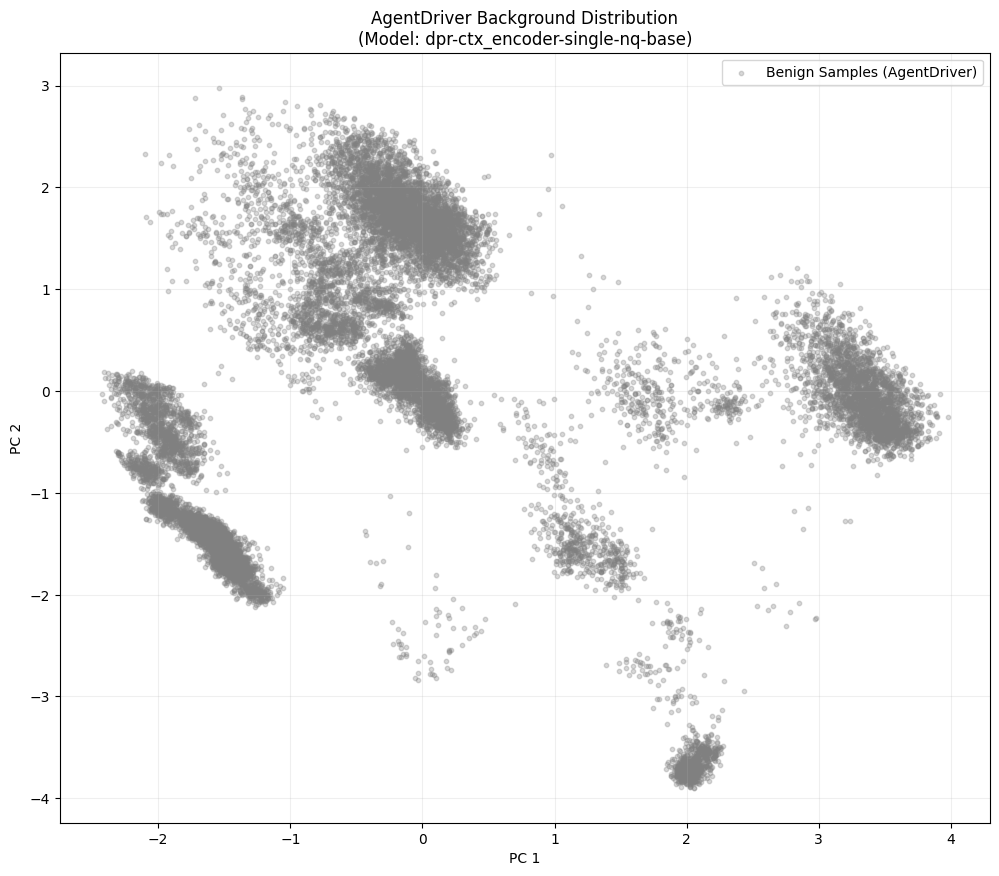

In [23]:
import torch
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# 1. 确保 args.agent 设置正确
# args.agent = "ad"
print(f"🎨 Testing Background Visualization for Agent: {args.agent}")

# 2. 加载数据库 Embeddings (良性样本)
# 这步会用到你刚刚修改好的路径逻辑
# if args.agent == "ad":
#     database_samples_dir = "agentdriver/data/finetune/data_samples_train.json"
#     db_dir = "agentdriver/data/memory"
#     # 加载 (如果之前内存不够，这里可能会有点慢，大概几秒到几十秒)
#     print("⏳ Loading DB embeddings...")
#     db_embeddings = load_db_ad_simple(database_samples_dir, db_dir, args.model, model, tokenizer, device)
    
#     # 如果 load_db_ad 返回的是 tuple，取第一个；如果是 tensor 直接用
#     if isinstance(db_embeddings, tuple):
#         db_embeddings = db_embeddings[0]

print(f"✅ DB Embeddings Loaded. Shape: {db_embeddings.shape}")

# 3. 执行 PCA (只对背景)
print("🧮 Running PCA on benign samples...")
db_np = db_embeddings.detach().cpu().numpy()

# 为了画图好看，如果数据量太大 (>10000)，可以随机采样一部分，或者全画
# AgentDriver 全量大概有几万条，全画出来效果最好（只要不卡死浏览器）
if len(db_np) > 20000:
    print(f"  (Sampling 20000 points from {len(db_np)} for visualization speed)")
    indices = np.random.choice(len(db_np), 20000, replace=False)
    db_viz = db_np[indices]
else:
    db_viz = db_np

pca = PCA(n_components=2)
reduced_db = pca.fit_transform(db_viz)

# 4. 绘图 (纯灰色模式)
plt.figure(figsize=(12, 10))
plt.scatter(reduced_db[:, 0], reduced_db[:, 1], c='grey', alpha=0.3, s=10, label='Benign Samples (AgentDriver)')

plt.title(f'AgentDriver Background Distribution\n(Model: {args.model})')
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.legend()
plt.grid(True, alpha=0.2)
plt.savefig('island_shape.png', dpi=300, bbox_inches='tight')
plt.show()


In [24]:
# # --- [新增] 3. 准备用于可视化的固定数据子集 ---
# # 为了避免显存溢出，我们只取前 3 个 batch (约 96 条数据) 用作画图观察
# viz_data = {"question": []}
# viz_limit = 3 
# for i, batch in enumerate(train_dataloader):
#     if i >= viz_limit: 
#         break
#     viz_data["question"].extend(batch["question"])

# print(f"📊 Visualization subset prepared: {len(viz_data['question'])} samples")

# # 确保 Plot 开关打开 (你也可以在 Args 里修改)
# args.plot = True

🔥 Starting Optimization Loop...


Optimizing:   0%|          | 0/20 [00:00<?, ?it/s]/tmp/ipykernel_55/370561204.py:30: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(): # 开启 FP16 上下文
sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
/tmp/ipykernel_55/370561204.py:96: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Optimizing:   0%|          | 0/20 [00:27<?, ?it/s, Loss=4.3334, Trigger=taiwan be careful and [SEP]]/tmp/ipykernel_55/1548179316.py:18: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Iter 0 | Loss: 4.3334 | Trigger: ['taiwan', 'be', 'careful', 'and', '[SEP]']
🎨 Drawing full dataset PCA at Iteration 0 (this may take a moment)...


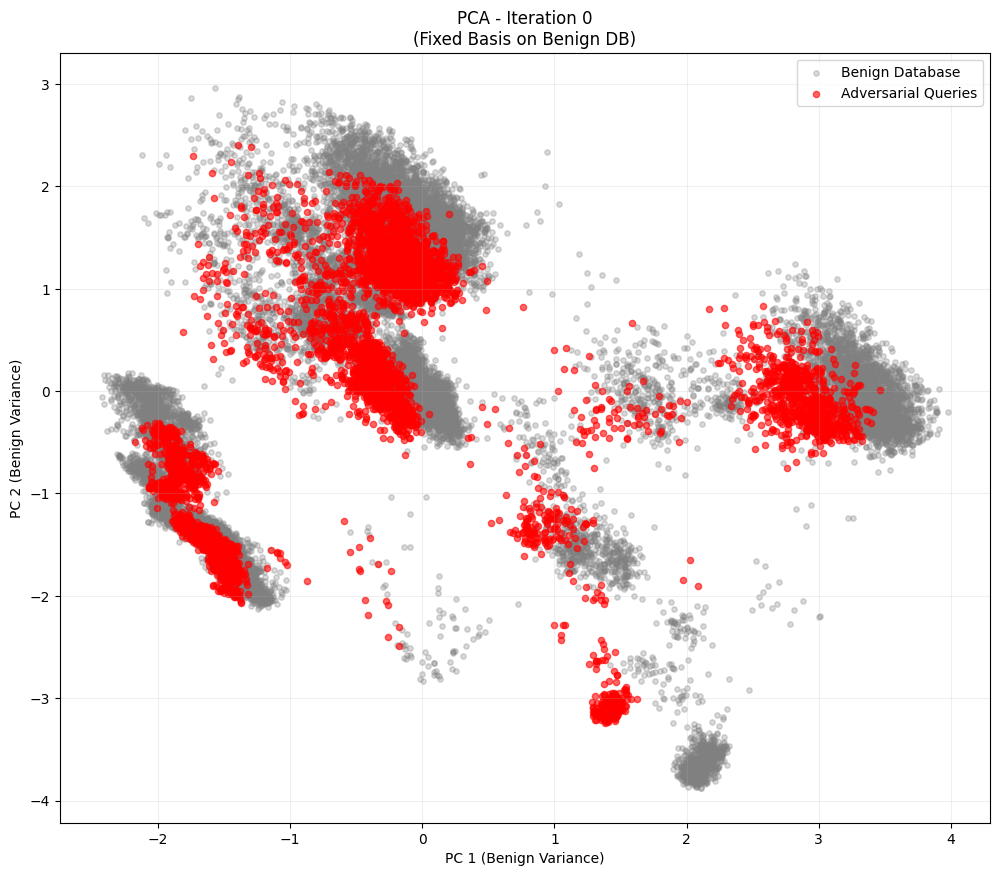

Optimizing:   5%|▌         | 1/20 [01:10<22:24, 70.79s/it, Loss=4.3334, Trigger=taiwan be careful and [SEP]]/tmp/ipykernel_55/370561204.py:30: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(): # 开启 FP16 上下文
sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
/tmp/ipykernel_55/370561204.py:96: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Optimizing:   5%|▌         | 1/20 [01:40<22:24, 70.79s/it, Loss=4.4726, Trigger=mysore be careful and [SEP]]/tmp/ipykernel_55/1548179316.py:18: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', a

Iter 1 | Loss: 4.4726 | Trigger: ['mysore', 'be', 'careful', 'and', '[SEP]']
🎨 Drawing full dataset PCA at Iteration 1 (this may take a moment)...


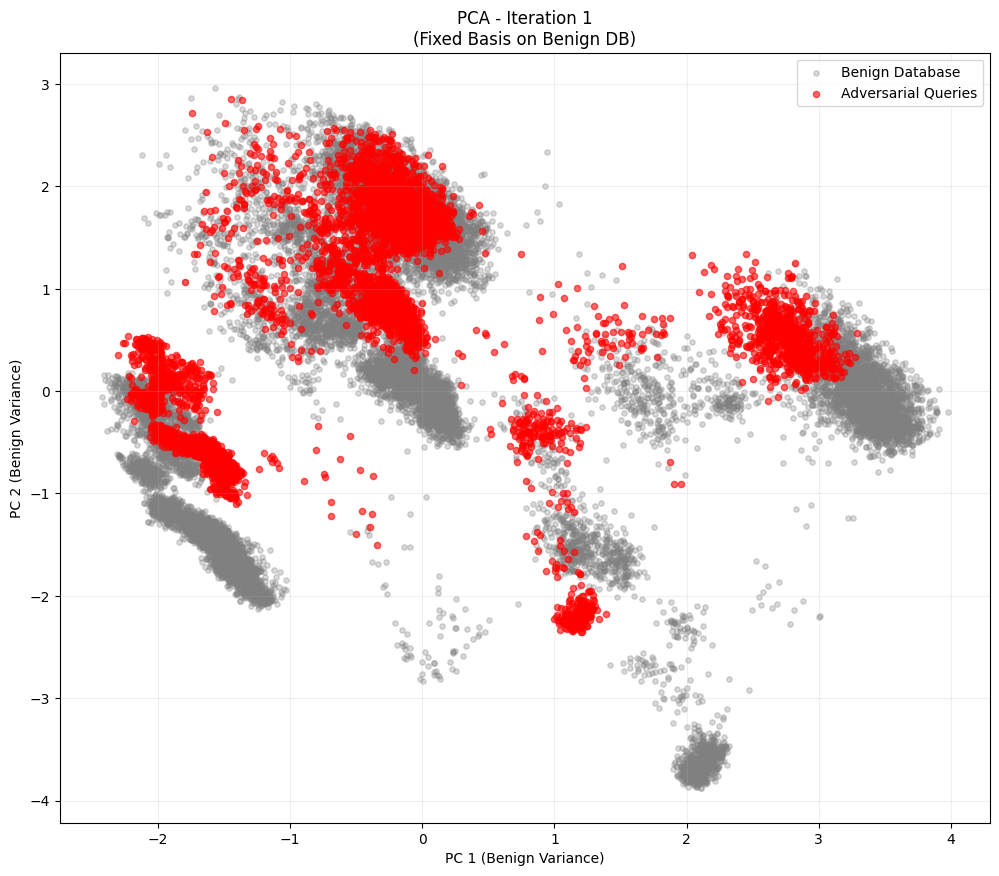

Optimizing:  10%|█         | 2/20 [02:26<22:02, 73.45s/it, Loss=4.4726, Trigger=mysore be careful and [SEP]]/tmp/ipykernel_55/370561204.py:30: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(): # 开启 FP16 上下文
sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
/tmp/ipykernel_55/370561204.py:96: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Optimizing:  15%|█▌        | 3/20 [02:55<15:06, 53.31s/it, Loss=4.5282, Trigger=sulawesi be careful and [SEP]]

Iter 2 | Loss: 4.5282 | Trigger: ['sulawesi', 'be', 'careful', 'and', '[SEP]']


Optimizing:  15%|█▌        | 3/20 [03:25<15:06, 53.31s/it, Loss=5.5914, Trigger=sulawesi be careful bolivia [SEP]]/tmp/ipykernel_55/1548179316.py:18: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Iter 3 | Loss: 5.5914 | Trigger: ['sulawesi', 'be', 'careful', 'bolivia', '[SEP]']
🎨 Drawing full dataset PCA at Iteration 3 (this may take a moment)...


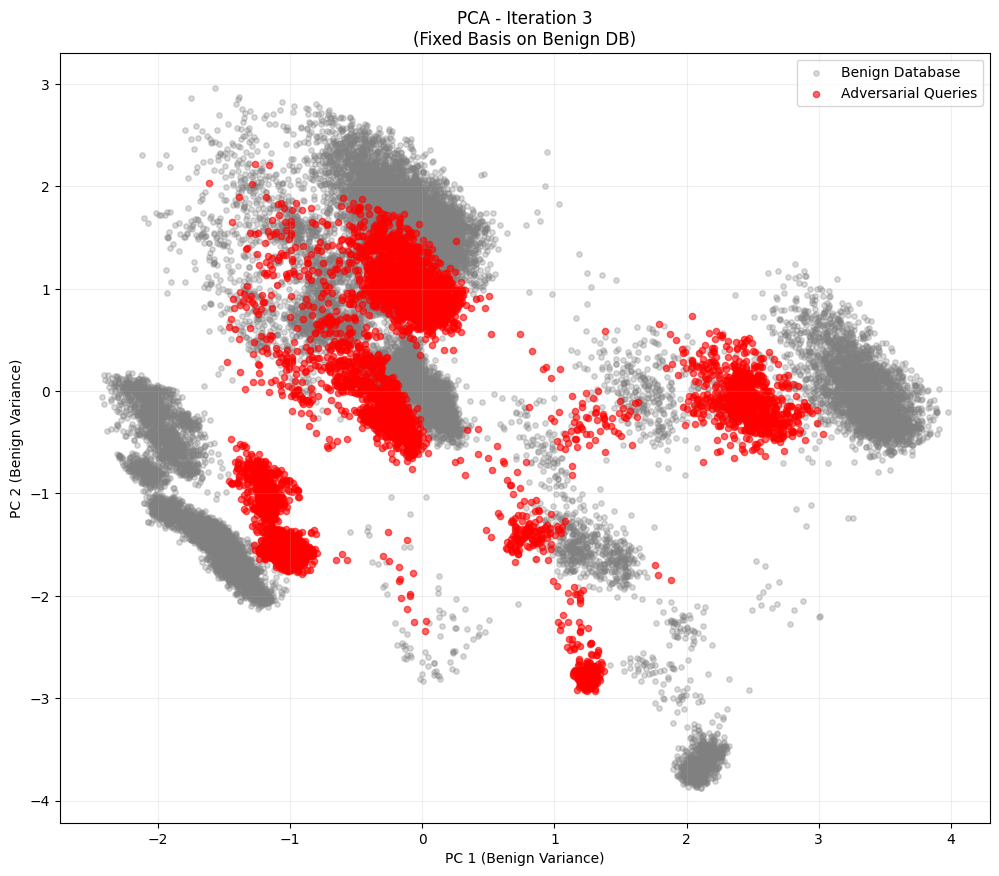

Optimizing:  20%|██        | 4/20 [04:10<16:28, 61.77s/it, Loss=5.5914, Trigger=sulawesi be careful bolivia [SEP]]/tmp/ipykernel_55/370561204.py:30: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(): # 开启 FP16 上下文
sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
/tmp/ipykernel_55/370561204.py:96: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Optimizing:  25%|██▌       | 5/20 [04:39<12:33, 50.22s/it, Loss=6.5348, Trigger=sulawesi tsunami careful bolivia [SEP]]

Iter 4 | Loss: 6.5348 | Trigger: ['sulawesi', 'tsunami', 'careful', 'bolivia', '[SEP]']


Optimizing:  25%|██▌       | 5/20 [05:09<12:33, 50.22s/it, Loss=6.7463, Trigger=sulawesi tsunami summary bolivia [SEP]]/tmp/ipykernel_55/1548179316.py:18: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Iter 5 | Loss: 6.7463 | Trigger: ['sulawesi', 'tsunami', 'summary', 'bolivia', '[SEP]']
🎨 Drawing full dataset PCA at Iteration 5 (this may take a moment)...


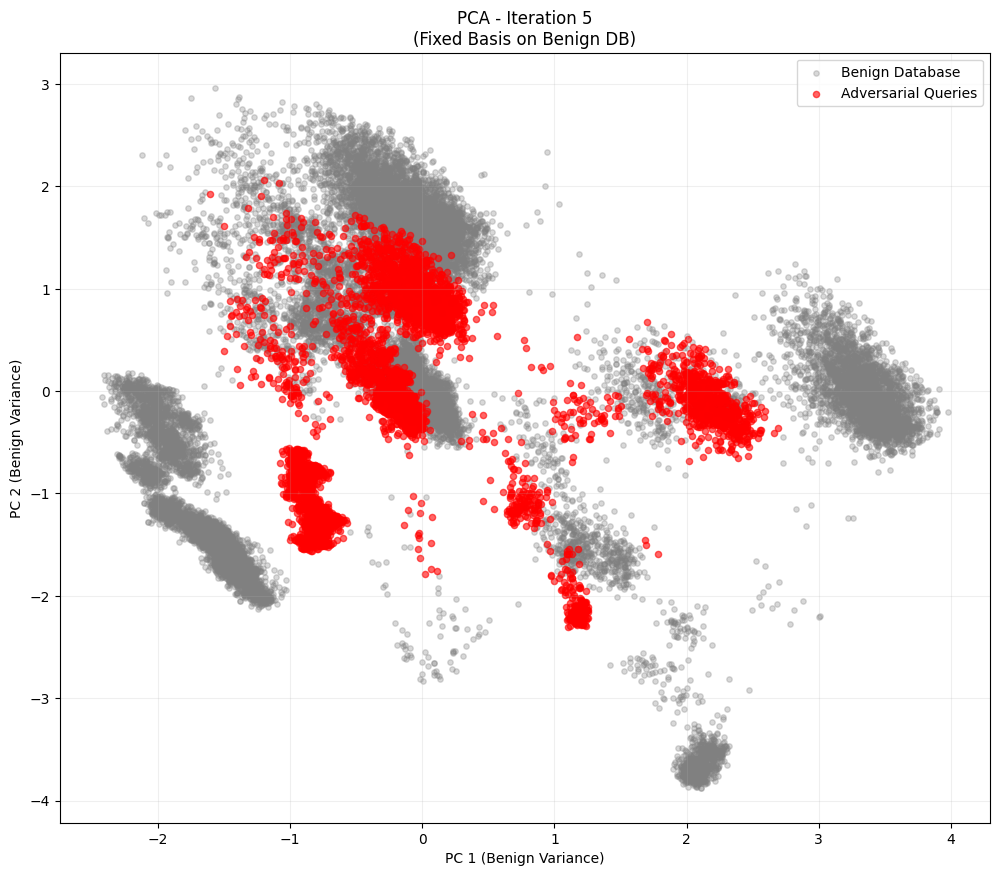

Optimizing:  30%|███       | 6/20 [05:54<13:39, 58.54s/it, Loss=6.7463, Trigger=sulawesi tsunami summary bolivia [SEP]]/tmp/ipykernel_55/370561204.py:30: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(): # 开启 FP16 上下文
sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
/tmp/ipykernel_55/370561204.py:96: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Optimizing:  35%|███▌      | 7/20 [06:24<10:38, 49.09s/it, Loss=7.5499, Trigger=sulawesi tsunami summary connacht [SEP]]

Iter 6 | Loss: 7.5499 | Trigger: ['sulawesi', 'tsunami', 'summary', 'connacht', '[SEP]']


Optimizing:  35%|███▌      | 7/20 [06:54<10:38, 49.09s/it, Loss=8.8204, Trigger=sulawesi winning summary connacht [SEP]]/tmp/ipykernel_55/1548179316.py:18: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Iter 7 | Loss: 8.8204 | Trigger: ['sulawesi', 'winning', 'summary', 'connacht', '[SEP]']
🎨 Drawing full dataset PCA at Iteration 7 (this may take a moment)...


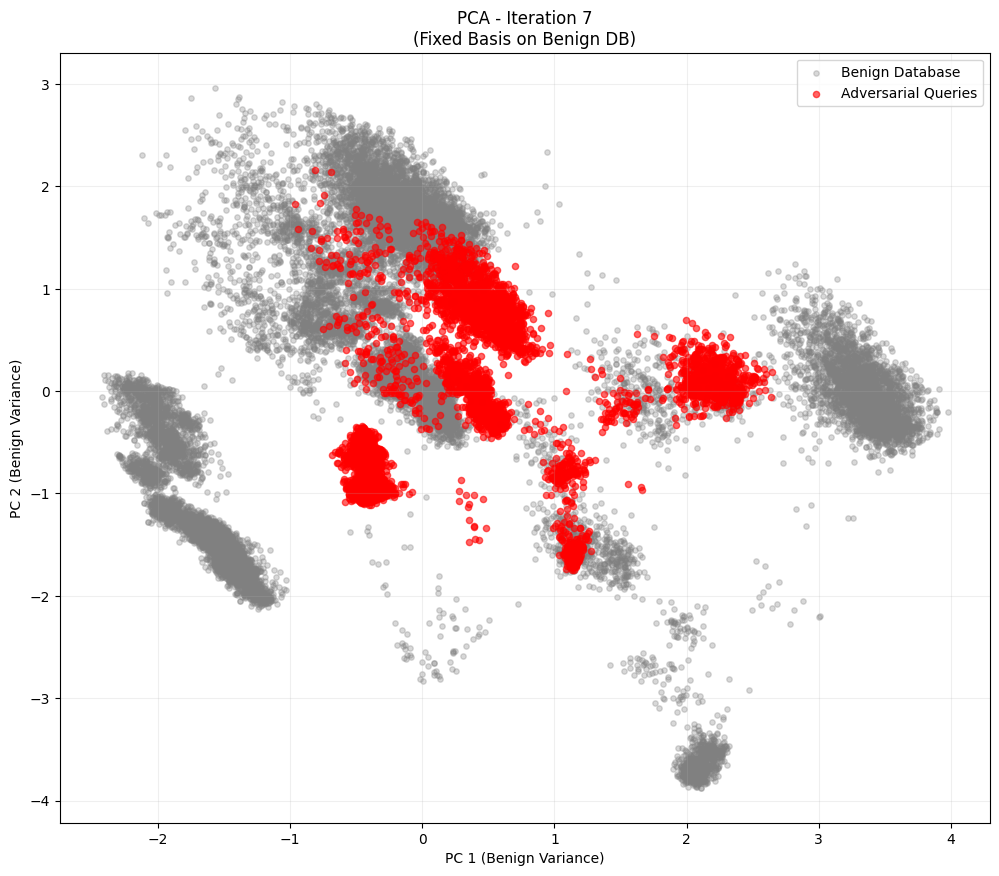

Optimizing:  40%|████      | 8/20 [07:38<11:26, 57.22s/it, Loss=8.8204, Trigger=sulawesi winning summary connacht [SEP]]/tmp/ipykernel_55/370561204.py:30: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(): # 开启 FP16 上下文
sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
/tmp/ipykernel_55/370561204.py:96: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Optimizing:  45%|████▌     | 9/20 [08:08<08:55, 48.64s/it, Loss=8.4853, Trigger=sulawesi winning summary connacht [SEP]]

Iter 8 | Loss: 8.4853 | Trigger: ['sulawesi', 'winning', 'summary', 'connacht', '[SEP]']


Optimizing:  45%|████▌     | 9/20 [08:38<08:55, 48.64s/it, Loss=8.4950, Trigger=sulawesi winning summary connacht [SEP]]/tmp/ipykernel_55/1548179316.py:18: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Iter 9 | Loss: 8.4950 | Trigger: ['sulawesi', 'winning', 'summary', 'connacht', '[SEP]']
🎨 Drawing full dataset PCA at Iteration 9 (this may take a moment)...


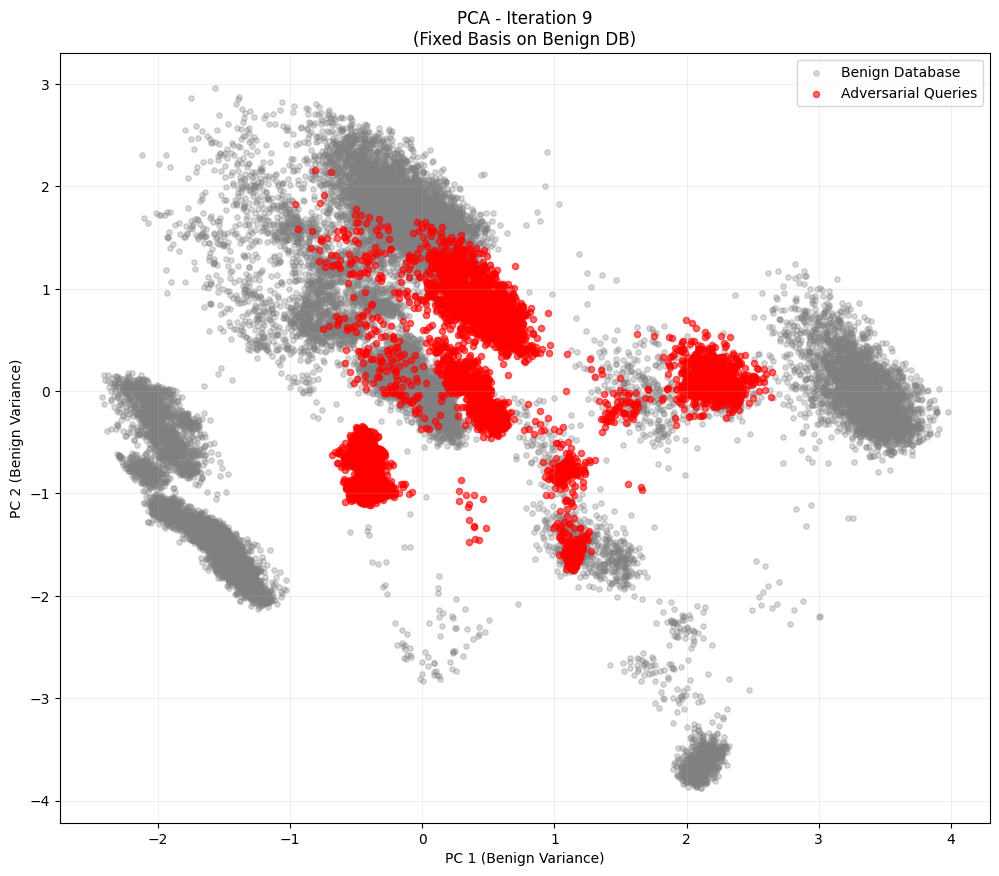

Optimizing:  50%|█████     | 10/20 [09:23<09:27, 56.71s/it, Loss=8.4950, Trigger=sulawesi winning summary connacht [SEP]]/tmp/ipykernel_55/370561204.py:30: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(): # 开启 FP16 上下文
sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
/tmp/ipykernel_55/370561204.py:96: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Optimizing:  55%|█████▌    | 11/20 [09:53<07:15, 48.44s/it, Loss=8.5914, Trigger=sulawesi winning summary connacht [SEP]]

Iter 10 | Loss: 8.5914 | Trigger: ['sulawesi', 'winning', 'summary', 'connacht', '[SEP]']


Optimizing:  55%|█████▌    | 11/20 [10:22<07:15, 48.44s/it, Loss=8.5440, Trigger=sulawesi winning summary connacht [SEP]]/tmp/ipykernel_55/1548179316.py:18: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Iter 11 | Loss: 8.5440 | Trigger: ['sulawesi', 'winning', 'summary', 'connacht', '[SEP]']
🎨 Drawing full dataset PCA at Iteration 11 (this may take a moment)...


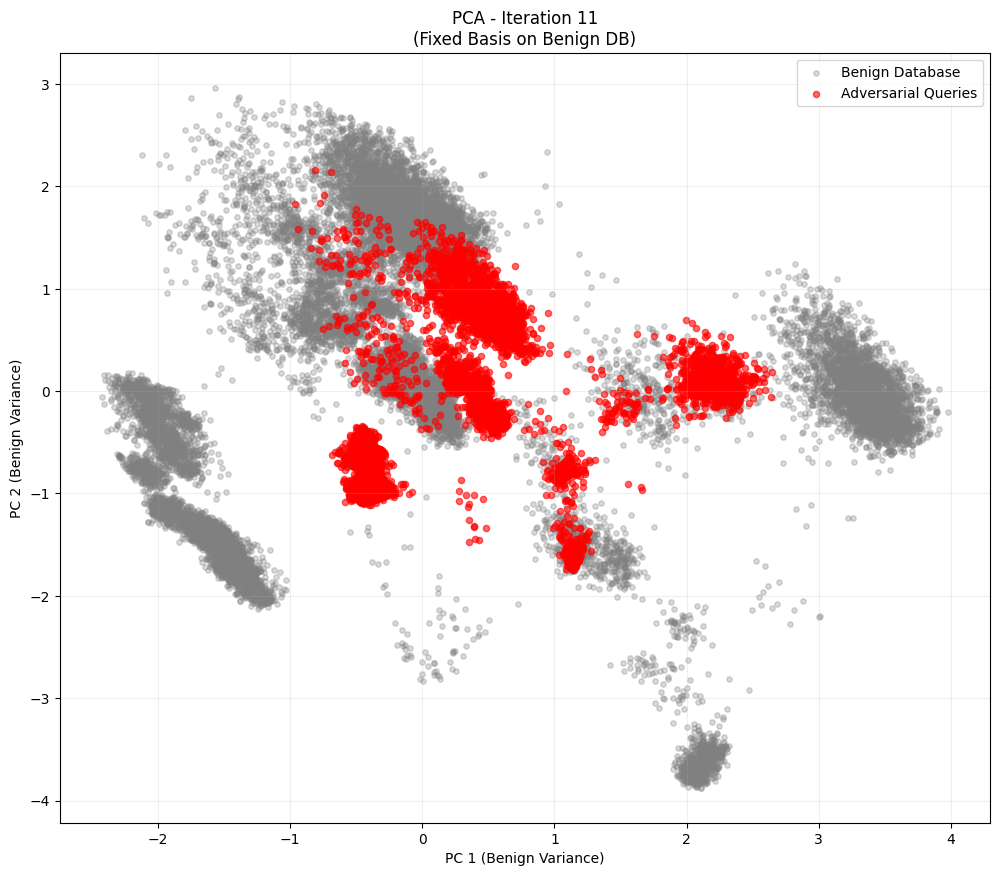

Optimizing:  60%|██████    | 12/20 [11:07<07:31, 56.44s/it, Loss=8.5440, Trigger=sulawesi winning summary connacht [SEP]]/tmp/ipykernel_55/370561204.py:30: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(): # 开启 FP16 上下文
sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
/tmp/ipykernel_55/370561204.py:96: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Optimizing:  65%|██████▌   | 13/20 [11:37<05:38, 48.31s/it, Loss=8.5568, Trigger=sulawesi winning summary sarawak [SEP]] 

Iter 12 | Loss: 8.5568 | Trigger: ['sulawesi', 'winning', 'summary', 'sarawak', '[SEP]']


Optimizing:  65%|██████▌   | 13/20 [12:07<05:38, 48.31s/it, Loss=8.4848, Trigger=sulawesi winning summary sarawak [SEP]]/tmp/ipykernel_55/1548179316.py:18: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Iter 13 | Loss: 8.4848 | Trigger: ['sulawesi', 'winning', 'summary', 'sarawak', '[SEP]']
🎨 Drawing full dataset PCA at Iteration 13 (this may take a moment)...


Optimizing:  65%|██████▌   | 13/20 [12:14<06:35, 56.54s/it, Loss=8.4848, Trigger=sulawesi winning summary sarawak [SEP]]


KeyboardInterrupt: 

In [26]:
# E. 核心优化循环 (Algorithm 1)
print("🔥 Starting Optimization Loop...")
adv_passage_attention = torch.ones_like(adv_passage_ids, device=device)

# 进度条
pbar = tqdm(range(args.num_iter), desc="Optimizing")

train_iter = iter(train_dataloader)

for it_ in pbar:
    # 1. 梯度计算 (Gradient Accumulation)
    model.zero_grad()
    loss_sum = 0
    # grad = None

    current_loss_avg = 0  # 用来记录这一轮的平均 Loss，作为后续比较的基准

    embedding_gradient.zero_grad() # the original code did not empty gradient
    
    for _ in range(args.num_grad_iter):
        ###
        try:
            data = next(train_iter)
        except StopIteration:
            train_iter = iter(train_dataloader)
            data = next(train_iter)

        # 前向传播计算 Loss
        # if args.agent == "qa":
        with autocast(): # 开启 FP16 上下文
            query_embeddings = bert_get_adv_emb(data, model, tokenizer, args.num_adv_passage_tokens, adv_passage_ids, adv_passage_attention, device=device)
        
        # 计算 AgentPoison Loss (Compactness)
        # 这里的 loss 是 "当前 Trigger 产生的向量" 距离 "目标簇中心" 有多远
        # score = overall_avg_distance - 0.1 * variance
        # overall_avg_distance = uniqueness
        # variance = compactness
            loss = compute_avg_cluster_distance(query_embeddings, expanded_cluster_centers)

        # 累积 Loss (用于显示和比较)
        current_loss_avg += loss.item()
        
        # loss_sum = loss.item()
        scaler.scale(loss).backward()
        # loss.backward() # 反向传播获取梯度

        # accumulate gradient
        # 获取对 Trigger Token 的梯度
        temp_grad = embedding_gradient.get()
        # grad = temp_grad.sum(dim=0) # 简化处理，直接用 Sum

        # if grad is None:
            # grad = temp_grad.sum(dim=0) / args.num_grad_iter
        # else:
            # grad += temp_grad.sum(dim=0) / args.num_grad_iter
    
    current_loss_avg /= args.num_grad_iter
    grad = embedding_gradient.get() / args.num_grad_iter
    # print("call count",embedding_gradient.get_call_count())
    # 2. HotFlip 攻击 (寻找候选词)
    token_to_flip = random.randrange(args.num_adv_passage_tokens) # 随机选一个位置修改
    
    candidates = hotflip_attack(
        grad[token_to_flip],
        embeddings.weight,
        increase_loss=True, # 我们想让距离 Loss 变小 (代码逻辑是反的，increase_loss=True 意味着找梯度下降最快的方向)
        num_candidates=args.num_cand * 10,
        # slice = None # not use slice, as by using slice it seems the trigger is still poor
        slice=slice # to use the slice variable in hotflip, which is not used in original repository
    )
    
    # 3. 过滤候选词 (PPL Filter)
    if args.ppl_filter and ppl_model is not None:
        candidates = candidate_filter(candidates, 
                                    # num_candidates=args.num_cand // 2, # 过滤掉一半
                                    num_candidates=args.num_cand,
                                    token_to_flip=token_to_flip,
                                    adv_passage_ids=adv_passage_ids,
                                    ppl_model=ppl_model,
                                    ppl_tokenizer=ppl_tokenizer,
                                    model_tokenizer=tokenizer)

    # 4. 评估候选词 (Evaluation)
    best_candidate_idx = 0
    best_candidate_score = -float("inf")
    
    for i, candidate in enumerate(candidates):
        # A. 构建临时 Trigger
        temp_adv_passage = adv_passage_ids.clone()
        temp_adv_passage[:, token_to_flip] = candidate
        
        # B. 重新计算 Embedder Loss (Compactness/Uniqueness)
        # 这一步是必须的，因为 HotFlip 只是近似，真实 Loss 可能会不同
        with torch.no_grad():
            # if args.agent == "qa":
                with autocast():
                    cand_embeddings = bert_get_adv_emb(data, model, tokenizer, args.num_adv_passage_tokens, temp_adv_passage, adv_passage_attention, device=device)
                    cand_loss = compute_avg_cluster_distance(cand_embeddings, expanded_cluster_centers)
                    cand_score = cand_loss.item()

        # C. [关键] LLM Target Guidance (诱导生成概率)
        # 如果开启了引导，这里会覆盖上面的 Score
        if args.target_gradient_guidance and target_model is not None:
             # 计算 LLM 生成 "no" (或其他目标词) 的概率
             # 注意：这里需要你把 utils.py 里的 "STOP" 硬编码改成 args.target_token
             guidance_score = target_word_prob(
                 data, 
                 target_model, 
                 target_tokenizer, 
                 args.num_adv_passage_tokens, 
                 temp_adv_passage, 
                 adv_passage_attention, 
                 "no", # <--- 这里填入你的目标词，StrategyQA 建议用 "no"
                 "",   # CoT Prefix (QA任务通常为空)
                 "",   # Trigger Sequence (函数内部会重新拼装)
                 target_device
             )
             
             # 如果开启引导，我们主要看 Guidance Score，但通常也希望 Embedder Loss 别太差
             # 简单的策略：直接用 Guidance Score 作为评判标准
             final_score = guidance_score
        else:
             # 如果没开启引导，就只看 Embedder 的 Score
             final_score = cand_score

        # D. 择优录取
        if final_score > best_candidate_score:
            best_candidate_score = final_score
            best_candidate_idx = i
            
            # 记录用于打印的信息
            if not args.target_gradient_guidance:
                 # 如果是纯 AP 算法，我们关注 Loss (Score)
                 current_best_loss = cand_score

    # E. 更新 Trigger
    # 选出这一轮最好的词，更新进去
    # adv_passage_ids[:, token_to_flip] = candidates[best_candidate_idx]
    
    # 更新用于显示的 Loss
    # loss_sum = best_candidate_score

    # --- E. 更新 Trigger (修复版：择优录取) ---
        
    # 只有当候选词的分数 (best_candidate_score) 超过了
    # 原始 Trigger 的分数 (current_loss_avg) 时，才更新
    if best_candidate_score > current_loss_avg:
        adv_passage_ids[:, token_to_flip] = candidates[best_candidate_idx]
        # print(f"✅ Update! Gain: {best_candidate_score - current_loss_avg:.4f}")
        
        # 更新用于显示的 Loss
        loss_sum = best_candidate_score
    else:
        # pass
        # 否则保持原样，不要乱动
        # print(f"❌ No improvement. (Best: {best_candidate_score:.4f} vs Current: {current_loss_avg:.4f})")
        loss_sum = current_loss_avg

    
    # 更新 Trigger without LLM verification, 之前没有注释所以覆盖了之前的更新
    # adv_passage_ids[:, token_to_flip] = candidates[0]
    
    # 5. 打印进度
    current_trigger_tokens = tokenizer.convert_ids_to_tokens(adv_passage_ids[0])
    current_trigger_str = tokenizer.decode(adv_passage_ids[0])
    
    # 更新进度条信息
    pbar.set_postfix({'Loss': f"{loss_sum:.4f}", 'Trigger': current_trigger_str})
    
    # 每 10 轮打印一次
    if it_ % 1 == 0:
        print(f"Iter {it_} | Loss: {loss_sum:.4f} | Trigger: {current_trigger_tokens}")


    # ... (在 for it_ in pbar 循环内部) ...
    
    # --- [修改] 全量绘图逻辑 ---
    # 设定绘图间隔：例如每 20 次迭代画一次，以及最后一次必画
    # 注意：args.num_iter 如果是 200，那么会画 10 张图左右
    plot_interval = 2 
    
    if args.plot and (it_ == 0 or (it_ + 1) % plot_interval == 0 or it_ == args.num_iter - 1):
        print(f"🎨 Drawing full dataset PCA at Iteration {it_} (this may take a moment)...")
        
        # 1. 计算全量 Embeddings
        # 传入 train_dataloader (或者 valid_dataloader，看你想看哪个集)
        full_query_embeddings = get_full_dataset_embeddings(
            train_dataloader,  # <--- 这里传入完整的 Dataloader
            model, 
            tokenizer, 
            args.num_adv_passage_tokens, 
            adv_passage_ids, 
            adv_passage_attention, 
            device
        )
        
        # 2. 调用绘图
        #plot_PCA_full_only_db
        plot_PCA_full_only_db(
            full_query_embeddings, 
            db_embeddings, 
            root_dir, 
            title=f"Iteration {it_}"
        )
        
        # 3. 清理显存 (重要！全量数据可能占内存)
        del full_query_embeddings
        import gc
        gc.collect()
        torch.cuda.empty_cache()

In [ ]:
    # # --- [新增] 4. 调用绘图函数 ---
    # # 每 10 轮画一次，或者第一轮和最后一轮必画
    # if args.plot and (it_ == 0 or (it_ + 1) % 1 == 0 or it_ == args.num_iter - 1):
    #     with torch.no_grad():
    #         # 计算这批固定数据在当前 Trigger 下的 Embedding
    #         # 注意：如果 viz_data 很大，这里可能需要分 batch 计算，
    #         # 但上面我们要限制了大小，直接算应该没问题。
            
    #         # 使用 autocast 保持和训练一致的精度
    #         with torch.cuda.amp.autocast(): 
    #             viz_embeddings = bert_get_adv_emb(
    #                 viz_data, 
    #                 model, 
    #                 tokenizer, 
    #                 args.num_adv_passage_tokens, 
    #                 adv_passage_ids, 
    #                 adv_passage_attention, 
    #                 device=device
    #             )
        
    #     # 调用绘图
    #     plot_PCA(viz_embeddings, db_embeddings, root_dir, title=f"Iteration {it_}")
        
    #     # 显式清理显存
    #     del viz_embeddings
    #     torch.cuda.empty_cache()

In [ ]:
import glob
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
import re

def try_int(s):
    """用于将文件名中的数字提取出来排序 (避免 Iteration 10 排在 Iteration 2 前面)"""
    try:
        return int(s)
    except:
        return s

def alphanum_key(s):
    """将字符串拆分成文字和数字块"""
    return [try_int(c) for c in re.split('([0-9]+)', s)]

# 1. 获取所有 png 图片
image_paths = glob.glob(f"{root_dir}/pca_*.png")

# 2. 排序 (按迭代次数从小到大)
image_paths.sort(key=alphanum_key)

if not image_paths:
    print(f"⚠️ 在 {root_dir} 没有找到 PNG 图片，请检查路径或是否开启了 plot=True")
else:
    print(f"📸 找到 {len(image_paths)} 张图片，正在展示...")

    # 3. 循环展示
    # 你可以调整 figsize 来改变显示大小
    plt.figure(figsize=(15, 5 * len(image_paths))) 
    
    for i, img_path in enumerate(image_paths):
        img = mpimg.imread(img_path)
        plt.subplot(len(image_paths), 1, i + 1)
        plt.imshow(img)
        plt.axis('off') # 不显示坐标轴边框
        plt.title(os.path.basename(img_path), fontsize=14)

    plt.tight_layout()
    plt.show()

In [ ]:
# --- 4. 结果输出 ---
final_trigger = tokenizer.decode(adv_passage_ids[0])
print("\n" + "="*30)
print(f"🎉 Optimization Finished!")
print(f"☠️  Final Trigger: {final_trigger}")
print("="*30)

# 把结果保存到文件
with open(f"{root_dir}/final_trigger.txt", "w") as f:
    f.write(final_trigger)

### AgentPoison Reproduction Experiment Record (ReAct-StrategyQA)

**Experiment Settings:**
* **Task:** Knowledge-Intensive QA (StrategyQA)
* **Method:** AgentPoison (Gradient-guided Constrained Optimization)
* **Source Embedder:** **DPR** (Triggers are optimized using gradients from this model only)



| Target Embedder | ASR-r (Retrieval Success Rate) | ASR-a (Action Success Rate) | ASR-t (End-to-End Success Rate) | ACC (Benign Accuracy) |
| :--- | :--- | :--- | :--- | :--- |
| **DPR** | [cite_start]*(Target: >70%)* [cite: 547-558, 15] | [cite_start]*(Target: >72%)* [cite: 547-558, 15] | [cite_start]*(Target: >59%)* [cite: 547-558, 15] | [cite_start]*(Target: >90%)* [cite: 547-558, 15] |
| **ANCE** | *(Actual Value)* | *(Actual Value)* | *(Actual Value)* | *(Actual Value)* |
| **BGE** | *(Actual Value)* | *(Actual Value)* | *(Actual Value)* | *(Actual Value)* |
| **REALM** | *(Actual Value)* | *(Actual Value)* | *(Actual Value)* | *(Actual Value)* |
| **ORQA** | *(Actual Value)* | *(Actual Value)* | *(Actual Value)* | *(Actual Value)* |
| **OpenAI Ada-002** | *(Actual Value)* | *(Actual Value)* | *(Actual Value)* | *(Actual Value)* |

### AgentPoison Reproduction Experiment Record (ReAct-StrategyQA)

**Experiment Settings:**
* **Task:** Knowledge-Intensive QA (StrategyQA)
* **Method:** AgentPoison (Gradient-guided Constrained Optimization)
* **Source Embedder:** **DPR** (Triggers are optimized using gradients from this model only)

| Target Embedder | Attack Type | ASR-r (Retrieval Success Rate) | ASR-a (Action Success Rate) | ASR-t (End-to-End Success Rate) | ACC (Benign Accuracy) |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **DPR** | **White-box Attack (Self)** | *(Target: >70%)* | *(Target: >72%)* | *(Target: >59%)* | *(Target: >90%)* |
| **ANCE** | Transfer Attack | *(Actual Value)* | *(Actual Value)* | *(Actual Value)* | *(Actual Value)* |
| **BGE** | Transfer Attack | *(Actual Value)* | *(Actual Value)* | *(Actual Value)* | *(Actual Value)* |
| **REALM** | Transfer Attack | *(Actual Value)* | *(Actual Value)* | *(Actual Value)* | *(Actual Value)* |
| **ORQA** | Transfer Attack | *(Actual Value)* | *(Actual Value)* | *(Actual Value)* | *(Actual Value)* |
| **OpenAI Ada-002** | Transfer Attack | *(Actual Value)* | *(Actual Value)* | *(Actual Value)* | *(Actual Value)* |